# Reinterpretation of Cross-Section Limits with Spey

 This tutorial shows how to convert cross-section limits into statistical models for inference using Spey. This approach will reinterpret cross-section curves as normal distributions for each mass point. This notebook reads the HEPData cross-section limits for the non-resonant RPV SUSY scenario from [arXiv:2206.09997](https://arxiv.org/abs/2206.09997), fits continuous interpolating functions, and constructs a **Spey** ``default.normal`` statistical model to compute exclusion $CL_s$ at arbitrary mass points and signal cross-sections.

**Source data:** HEPData record `ins2098256-v1`, [Table 14 (Figure 12)](https://doi.org/10.17182/hepdata.130817.v1/t14).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import spey
import warnings

warnings.filterwarnings("ignore")

Spey - WARNING: An unstable version of Spey (0.2.7-b2) is being used. Latest stable version is 0.2.6.


## 1. Read and Parse the CSV Data

You will need to download the CSV data from HEPData for this part.

In [ ]:
def parse_hepdata_csv(filepath):
    """Parse multi-block HEPData CSV into a dict of {label: (mass, values)} arrays.

    Each block is separated by a header line containing column names.
    Generic for any HEPData CSV with the same structure.
    """
    blocks = {}
    current_label = None
    masses, values = [], []

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split(",")
            try:
                float(parts[0])
            except ValueError:
                if current_label is not None and masses:
                    blocks[current_label] = (np.array(masses), np.array(values))
                current_label = parts[1].strip()
                masses, values = [], []
                continue
            masses.append(float(parts[0]))
            values.append(float(parts[1]))

    if current_label and masses:
        blocks[current_label] = (np.array(masses), np.array(values))

    return blocks


CSV_PATH = "HEPData-ins2098256-v1-Cross-section_limits_-_non_resonant_scenario.csv"
data = parse_hepdata_csv(CSV_PATH)

# Readable key mapping
KEYS = {
    "obs": "95% CL observed upper limits [pb]",
    "exp": "95% CL expected upper limits [pb]",
    "m1": "95% CL expected -1 s.d. upper limits [pb]",
    "p1": "95% CL expected +1 s.d. upper limits [pb]",
    "m2": "95% CL expected -2 s.d. upper limits [pb]",
    "p2": "95% CL expected +2 s.d. upper limits [pb]",
    "theory": "SUSY top squark cross section times acceptance [pb]",
}

for key, label in KEYS.items():
    mass, vals = data[label]
    print(f"{key:6s}: {len(mass)} points, mass range [{mass[0]:.0f}, {mass[-1]:.0f}] GeV")

obs   : 43 points, mass range [500, 3000] GeV
exp   : 43 points, mass range [500, 3000] GeV
m1    : 43 points, mass range [500, 3000] GeV
p1    : 43 points, mass range [500, 3000] GeV
m2    : 43 points, mass range [500, 3000] GeV
p2    : 43 points, mass range [500, 3000] GeV
theory: 43 points, mass range [500, 3000] GeV


## 2. Fit Interpolating Functions

Cubic splines in **log-log space** (`log(mass)` vs `log(cross-section)`) ensure
positive-definite interpolation across several orders of magnitude.
This approach is generic for any similar cross-section distribution.

In [3]:
class LogSplineInterpolator:
    """Cubic spline interpolation in log-log space.

    Parameters
    ----------
    mass : array-like
        Mass points in GeV.
    values : array-like
        Cross-section (or limit) values in pb.
    """

    def __init__(self, mass, values):
        self.mass_min = mass.min()
        self.mass_max = mass.max()
        self._spline = CubicSpline(np.log(mass), np.log(values))

    def __call__(self, m):
        m = np.asarray(m, dtype=float)
        return np.exp(self._spline(np.log(m)))

    def domain(self):
        return self.mass_min, self.mass_max


# Build interpolators for every curve
interp = {}
for key, label in KEYS.items():
    mass, vals = data[label]
    interp[key] = LogSplineInterpolator(mass, vals)

print("Interpolators built for:", list(interp.keys()))

Interpolators built for: ['obs', 'exp', 'm1', 'p1', 'm2', 'p2', 'theory']


## 3. Validation Plot — Reproducing Figure 12

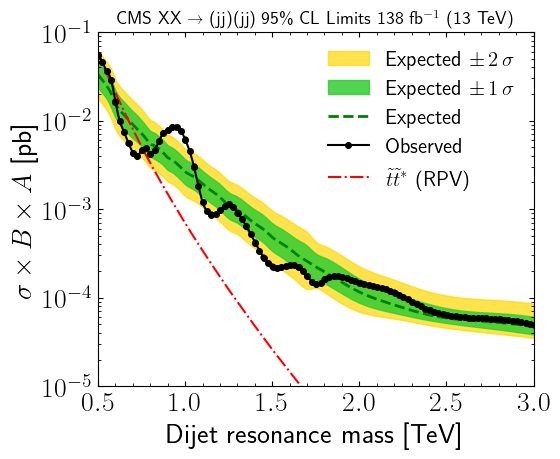

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

m_fine = np.linspace(500, 3000, 500)

# 2-sigma band
ax.fill_between(
    m_fine / 1000,
    interp["m2"](m_fine),
    interp["p2"](m_fine),
    color="gold",
    alpha=0.7,
    label=r"Expected $\pm\,2\,\sigma$",
)
# 1-sigma band
ax.fill_between(
    m_fine / 1000,
    interp["m1"](m_fine),
    interp["p1"](m_fine),
    color="limegreen",
    alpha=0.85,
    label=r"Expected $\pm\,1\,\sigma$",
)
# Expected limit
ax.plot(m_fine / 1000, interp["exp"](m_fine), "g--", lw=2, label="Expected")
# Observed limit
ax.plot(
    m_fine / 1000,
    interp["obs"](m_fine),
    "k-o",
    ms=4,
    lw=1.5,
    label="Observed",
    markevery=5,
    zorder=5,
)
# Theory cross-section
ax.plot(
    m_fine / 1000,
    interp["theory"](m_fine),
    "r-.",
    lw=1.5,
    label=r"$\tilde{t}\tilde{t}^*$ (RPV)",
)

# Overlay digitised points
mass_obs, vals_obs = data[KEYS["obs"]]
ax.plot(mass_obs / 1000, vals_obs, "ko", ms=3.5, zorder=6)

ax.set_yscale("log")
ax.set_xlabel("Dijet resonance mass [TeV]")
ax.set_ylabel(r"$\sigma \times B \times A$ [pb]")
ax.set_title(r"CMS  XX → (jj)(jj)   95\% CL Limits   138 fb$^{-1}$ (13 TeV)", fontsize=13)
ax.set_xlim(0.5, 3.0)
ax.set_ylim(1e-5, 1e-1)
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

## 4. Spey Statistical Model Construction

### Mapping cross-section limits to model parameters

For the `default.normal` backend the likelihood at each mass point is

$$\mathcal{L}(\mu) = \frac{1}{\sigma\sqrt{2\pi}}
\exp\!\left[-\frac{1}{2}\left(
\frac{\mu\, \sigma_{\text{sig}} + \sigma_{\text{exp}} - \sigma_{\text{obs}}}{\delta\sigma}
\right)^{\!2}\right]$$

where every quantity lives in cross-section space (pb):

| Spey parameter | Physical meaning | Source |
|---|---|---|
| `signal_yields` | $\sigma_{\text{sig}}$: BSM signal $\sigma\times B\times A$ | theory curve |
| `background_yields` | $\sigma_{\text{exp}}$: expected (SM-only) limit | CSV expected limit |
| `data` | $\sigma_{\text{obs}}$: observed limit | CSV observed limit |
| `absolute_uncertainties` | $\delta\sigma$: $1\sigma$ uncertainty on the expected limit | $(\sigma_{+1\sigma} - \sigma_{-1\sigma})/2$ |

In [ ]:
NORMAL_BACKEND = spey.get_backend("default.normal")


def build_spey_model(mass, signal_xsec):
    """Construct a Spey `default.normal` model at a given mass point.

    Parameters
    ----------
    mass : float
        Resonance mass in GeV.
    signal_xsec : float
        BSM signal cross-section × branching fraction × acceptance [pb].
        Must use the same BR × A conventions as the CMS limits.

    Returns
    -------
    model : spey.StatisticalModel
    params : dict
        Derived parameters for diagnostics.
    """
    obs_lim = float(interp["obs"](mass))
    exp_lim = float(interp["exp"](mass))
    m1_lim = float(interp["m1"](mass))
    p1_lim = float(interp["p1"](mass))
    m2_lim = float(interp["m2"](mass))
    p2_lim = float(interp["p2"](mass))

    # 1-sigma uncertainty on the expected limit from the ±1σ band
    sigma_unc = (p1_lim - m1_lim) / 2.0

    model = NORMAL_BACKEND(
        signal_yields=[signal_xsec],
        background_yields=[exp_lim],
        data=[obs_lim],
        absolute_uncertainties=[sigma_unc],
        analysis=f"CMS-EXO-21-010_nonres_m{mass:.0f}",
    )

    params = dict(
        mass=mass,
        signal_xsec=signal_xsec,
        obs_limit=obs_lim,
        exp_limit=exp_lim,
        m1_limit=m1_lim,
        p1_limit=p1_lim,
        m2_limit=m2_lim,
        p2_limit=p2_lim,
        sigma_unc=sigma_unc,
    )
    return model, params


def compute_exclusion(mass, signal_xsec):
    """Compute exclusion confidence level (1 − CLs) at μ = 1.

    Parameters
    ----------
    mass : float
        Resonance mass in GeV.
    signal_xsec : float
        BSM signal σ × B × A [pb].

    Returns
    -------
    excl_obs : float
        Observed 1 − CLs.  Signal excluded at 95% CL when ≥ 0.95.
    excl_exp : list[float]
        Expected 1 − CLs: [-2σ, -1σ, median, +1σ, +2σ].
    """
    model, params = build_spey_model(mass, signal_xsec)

    excl_obs = model.exclusion_confidence_level(
        poi_test=1.0, expected=spey.ExpectationType.observed
    )
    excl_exp = model.exclusion_confidence_level(
        poi_test=1.0, expected=spey.ExpectationType.aposteriori
    )
    return float(excl_obs[0]), [float(x) for x in excl_exp]


# Quick test using the CSV theory cross-section
for m_test in [500, 700, 1000]:
    theory_xs = float(interp["theory"](m_test))
    model_t, p_t = build_spey_model(m_test, theory_xs)
    print(
        f"m = {m_test} GeV:  theory = {theory_xs:.4e} pb,  "
        f"obs = {p_t['obs_limit']:.4e},  exp = {p_t['exp_limit']:.4e},  "
        f"σ_unc = {p_t['sigma_unc']:.4e}"
    )

m = 500 GeV:  theory = 5.9032e-02 pb,  obs = 5.4735e-02,  exp = 3.3169e-02,  σ_unc = 1.0933e-02
m = 700 GeV:  theory = 8.0006e-03 pb,  obs = 4.3525e-03,  exp = 9.0205e-03,  σ_unc = 3.2119e-03
m = 1000 GeV:  theory = 6.9786e-04 pb,  obs = 6.1573e-03,  exp = 2.6542e-03,  σ_unc = 8.7190e-04


## 5. Exclusion $CL_s$ Evaluation

In [19]:
# ──────────────────────────────────────────────────────
# USER INPUTS — change these to query different points
# ──────────────────────────────────────────────────────
QUERY_MASS = 1000.0  # GeV
SIGNAL_XSEC = 0.001  # pb  (σ × B × A)
# ──────────────────────────────────────────────────────

excl_obs, excl_exp = compute_exclusion(QUERY_MASS, SIGNAL_XSEC)

print(f"Mass = {QUERY_MASS:.0f} GeV,  σ×B×A = {SIGNAL_XSEC:.1e} pb")
print(f"{'─' * 55}")
print(f"  Observed  CLs = {excl_obs:.4f} ")
print(f"  Expected  CLs:")
labels = ["  −2σ", "  −1σ", "  med", "  +1σ", "  +2σ"]
for lbl, val in zip(labels, excl_exp):
    print(f"    {lbl}: CLs = {val:.4f}")
excluded = excl_obs >= 0.95
print(f"\n  → Signal {'IS' if excluded else 'is NOT'} excluded at 95% CL.")

Mass = 1000 GeV,  σ×B×A = 1.0e-03 pb
───────────────────────────────────────────────────────
  Observed  CLs = 0.4281 
  Expected  CLs:
      −2σ: CLs = 0.9637
      −1σ: CLs = 0.8998
      med: CLs = 0.7486
      +1σ: CLs = 0.4751
      +2σ: CLs = 0.1781

  → Signal is NOT excluded at 95% CL.


### Exclusion scan: theory cross-section across mass

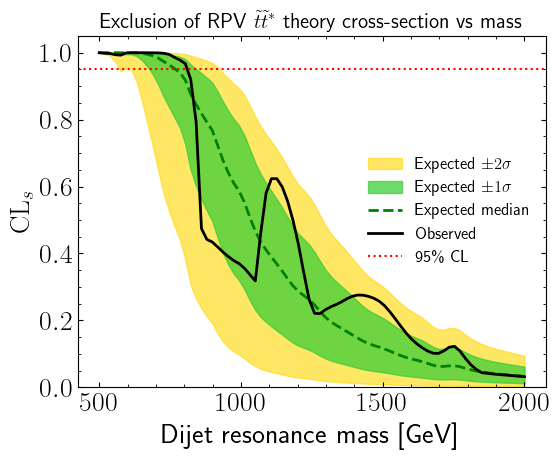

In [ ]:
mass_scan = np.linspace(500, 2000, 80)

excl_obs_arr = []
excl_exp_arr = []
for m in mass_scan:
    theory_xs = float(interp["theory"](m))
    eo, ee = compute_exclusion(m, theory_xs)
    excl_obs_arr.append(eo)
    excl_exp_arr.append(ee)

excl_obs_arr = np.array(excl_obs_arr)
excl_exp_arr = np.array(excl_exp_arr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.fill_between(
    mass_scan,
    excl_exp_arr[:, 0],
    excl_exp_arr[:, 4],
    color="gold",
    alpha=0.6,
    label=r"Expected $\pm 2\sigma$",
)
ax.fill_between(
    mass_scan,
    excl_exp_arr[:, 1],
    excl_exp_arr[:, 3],
    color="limegreen",
    alpha=0.7,
    label=r"Expected $\pm 1\sigma$",
)
ax.plot(mass_scan, excl_exp_arr[:, 2], "g--", lw=2, label="Expected median")
ax.plot(mass_scan, excl_obs_arr, "k-", lw=2, label="Observed")
ax.axhline(0.95, color="red", ls=":", lw=1.5, label=r"95\% CL")
ax.set_xlabel("Dijet resonance mass [GeV]")
ax.set_ylabel(r"$\mathrm{CL}_s$")
ax.set_title(
    r"Exclusion of RPV $\tilde{t}\tilde{t}^*$ theory cross-section vs mass", fontsize=15
)
ax.legend(loc="center right", fontsize=12)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()